In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']    = (12, 6)
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'primary'  : '#2C3E50',
    'profit'   : '#27AE60',
    'revenue'  : '#2980B9',
    'cost'     : '#E74C3C',
    'warning'  : '#F39C12',
    'highlight': '#8E44AD'
}

DIVISION_COLORS = {
    'Chocolate': '#27AE60',
    'Sugar'    : '#2980B9',
    'Other'    : '#F39C12'
}

In [2]:
df = pd.read_csv('../data/nassau_candy_enriched.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Quarter']    = df['Order Date'].dt.quarter

print(f"Data loaded: {df.shape[0]} rows")

Data loaded: 6013 rows


### Prepare Division Summary

In [3]:
total_revenue = df['Sales'].sum()
total_profit  = df['Gross Profit'].sum()

division_summary = df.groupby('Division').agg(
    Total_Revenue = ('Sales', 'sum'),
    Total_Profit  = ('Gross Profit', 'sum'),
    Total_Cost    = ('Cost', 'sum'),
    Total_Units   = ('Units', 'sum'),
    Avg_Margin    = ('Gross_Margin_%', 'mean')
).round(2).reset_index()

division_summary['Revenue_Share_%'] = (
    division_summary['Total_Revenue'] / total_revenue * 100
).round(2)

division_summary['Profit_Share_%'] = (
    division_summary['Total_Profit'] / total_profit * 100
).round(2)

division_summary = division_summary.sort_values('Total_Revenue', ascending=False).reset_index(drop=True)

print(division_summary[['Division', 'Total_Revenue', 'Total_Profit', 
                         'Avg_Margin', 'Revenue_Share_%', 'Profit_Share_%']])

    Division  Total_Revenue  Total_Profit  Avg_Margin  Revenue_Share_%  \
0  Chocolate       77573.34      52353.28       67.49            92.54   
1      Other        5906.25       2698.45       39.01             7.05   
2      Sugar         347.84        239.64       58.75             0.41   

   Profit_Share_%  
0           94.69  
1            4.88  
2            0.43  


### Chart 10: Division Revenue Share Donut

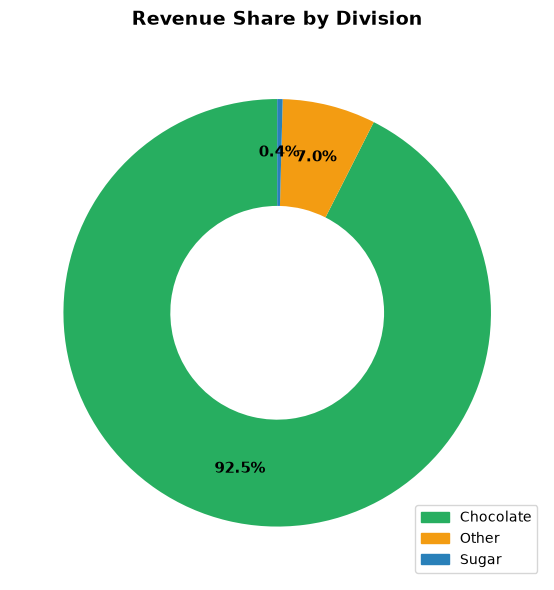

Chart 10 saved


In [4]:
colors = [DIVISION_COLORS[d] for d in division_summary['Division']]

fig, ax = plt.subplots()

wedges, texts, autotexts = ax.pie(
    division_summary['Revenue_Share_%'],
    labels=None,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5)
)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title('Revenue Share by Division', fontsize=14, fontweight='bold', pad=15)
ax.legend(
    handles=[plt.Rectangle((0,0), 1, 1, color=DIVISION_COLORS[d], label=d)
             for d in division_summary['Division']],
    loc='lower right'
)

plt.tight_layout()
plt.savefig('../outputs/charts/10_division_revenue_share_donut.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 10 saved")

### Chart 11: Division Profit Share Donut

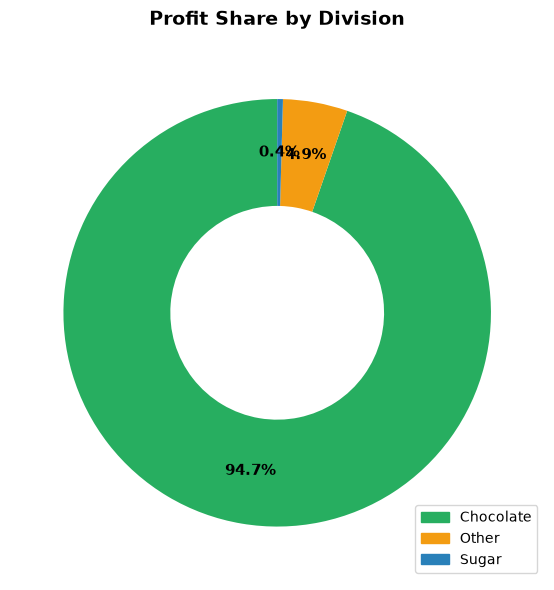

Chart 11 saved


In [5]:
colors = [DIVISION_COLORS[d] for d in division_summary['Division']]

fig, ax = plt.subplots()

wedges, texts, autotexts = ax.pie(
    division_summary['Profit_Share_%'],
    labels=None,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5)
)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title('Profit Share by Division', fontsize=14, fontweight='bold', pad=15)
ax.legend(
    handles=[plt.Rectangle((0,0), 1, 1, color=DIVISION_COLORS[d], label=d)
             for d in division_summary['Division']],
    loc='lower right'
)

plt.tight_layout()
plt.savefig('../outputs/charts/11_division_profit_share_donut.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 11 saved")

### Chart 12: Avg Margin by Division

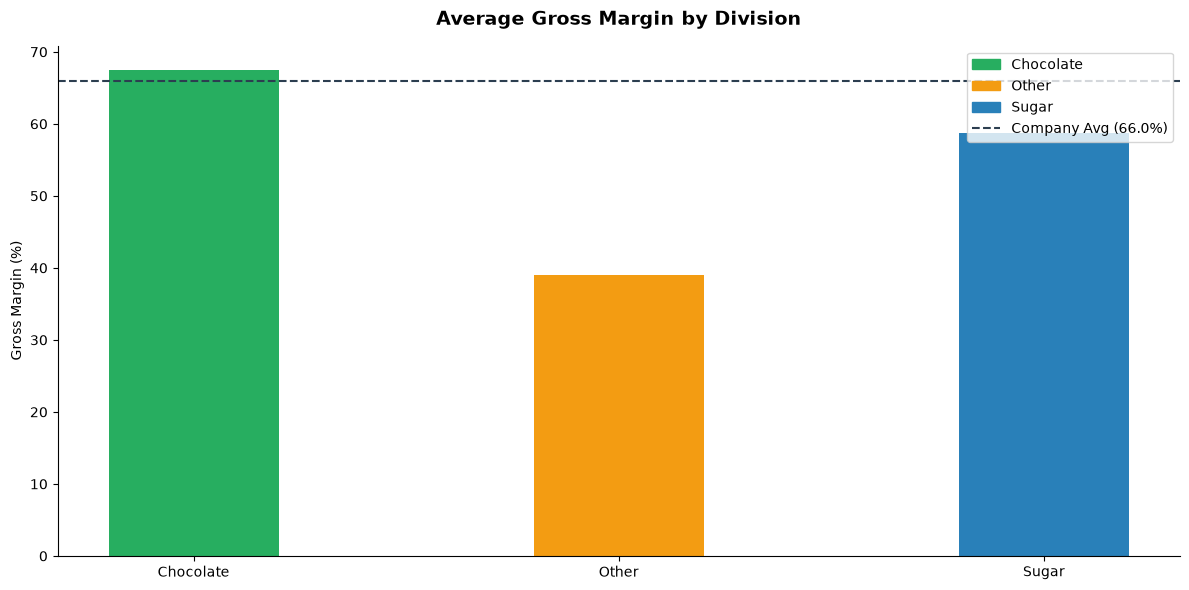

Chart 12 saved


In [6]:
colors = [DIVISION_COLORS[d] for d in division_summary['Division']]
company_avg_margin = (total_profit / total_revenue * 100)

fig, ax = plt.subplots()

bars = ax.bar(division_summary['Division'], division_summary['Avg_Margin'],
              color=colors, width=0.4)

ax.axhline(y=company_avg_margin, color=COLORS['primary'],
           linestyle='--', linewidth=1.5)

ax.set_title('Average Gross Margin by Division', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Gross Margin (%)')
ax.set_xlabel('')

ax.legend(handles=[
    plt.Rectangle((0,0), 1, 1, color=DIVISION_COLORS[d], label=d)
    for d in division_summary['Division']
] + [
    plt.Line2D([0], [0], color=COLORS['primary'], linestyle='--',
               label=f'Company Avg ({company_avg_margin:.1f}%)')
], loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/charts/12_division_avg_margin.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 12 saved")

### Chart 13: Revenue vs Profit Stacked Bar

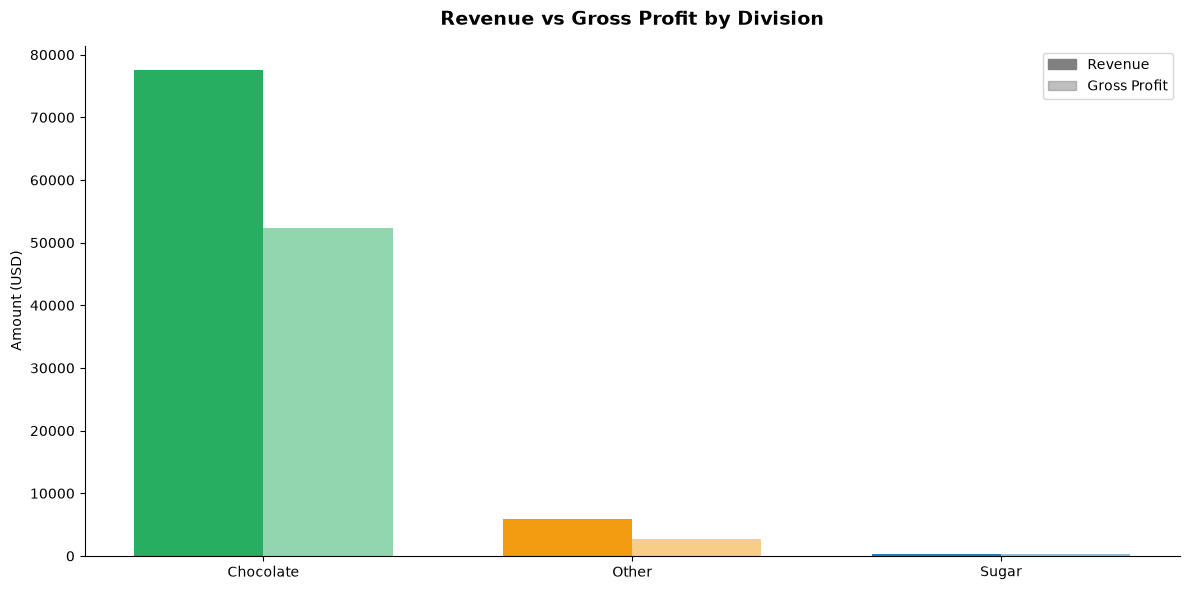

Chart 13 saved


In [7]:
fig, ax = plt.subplots()

x     = np.arange(len(division_summary))
width = 0.35

ax.bar(x - width/2, division_summary['Total_Revenue'], width,
       color=[DIVISION_COLORS[d] for d in division_summary['Division']],
       label='Revenue', alpha=1.0)

ax.bar(x + width/2, division_summary['Total_Profit'], width,
       color=[DIVISION_COLORS[d] for d in division_summary['Division']],
       label='Gross Profit', alpha=0.5)

ax.set_title('Revenue vs Gross Profit by Division', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Amount (USD)')
ax.set_xticks(x)
ax.set_xticklabels(division_summary['Division'])

ax.legend(handles=[
    plt.Rectangle((0,0), 1, 1, color='grey', alpha=1.0, label='Revenue'),
    plt.Rectangle((0,0), 1, 1, color='grey', alpha=0.5, label='Gross Profit')
], loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/charts/13_division_revenue_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 13 saved")

Prepare Quarterly by Division

In [8]:
quarterly_div = df.groupby(['Division', 'Quarter']).agg(
    Total_Revenue = ('Sales', 'sum'),
    Total_Profit  = ('Gross Profit', 'sum'),
    Avg_Margin    = ('Gross_Margin_%', 'mean')
).round(2).reset_index()

quarterly_div['Quarter_Label'] = 'Q' + quarterly_div['Quarter'].astype(str)

print(quarterly_div)

     Division  Quarter  Total_Revenue  Total_Profit  Avg_Margin Quarter_Label
0   Chocolate        1       10787.75       7285.15       67.55            Q1
1   Chocolate        2       16648.80      11238.64       67.48            Q2
2   Chocolate        3       21310.90      14375.06       67.52            Q3
3   Chocolate        4       28825.89      19454.43       67.46            Q4
4       Other        1         641.00        283.40       44.22            Q1
5       Other        2         929.25        397.85       32.20            Q2
6       Other        3        1898.00        869.60       37.53            Q3
7       Other        4        2438.00       1147.60       40.68            Q4
8       Sugar        1          37.24         26.19       61.69            Q1
9       Sugar        2         115.00         82.60       58.61            Q2
10      Sugar        3          46.47         32.62       62.82            Q3
11      Sugar        4         149.13         98.23       56.50 

### Chart 14: Quarterly Revenue Trend by Division

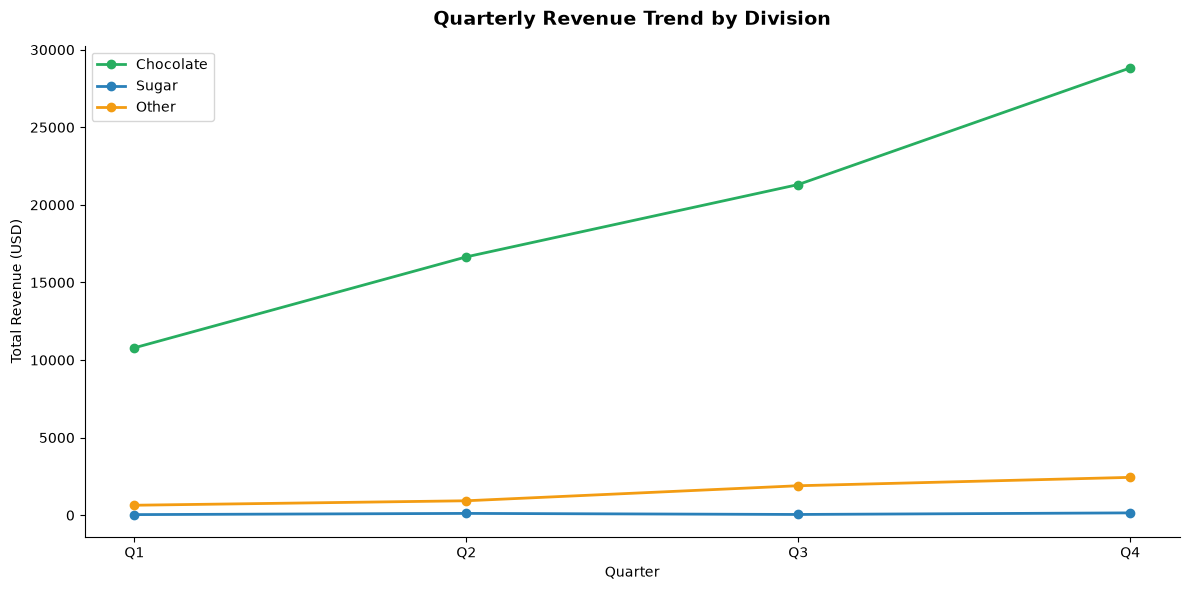

Chart 14 saved


In [9]:
fig, ax = plt.subplots()

for division, color in DIVISION_COLORS.items():
    subset = quarterly_div[quarterly_div['Division'] == division]
    ax.plot(subset['Quarter_Label'], subset['Total_Revenue'],
            color=color, marker='o', linewidth=2, label=division)

ax.set_title('Quarterly Revenue Trend by Division', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Revenue (USD)')
ax.set_xlabel('Quarter')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/charts/14_division_quarterly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 14 saved")

### Chart 15: Quarterly Margin Trend by Division

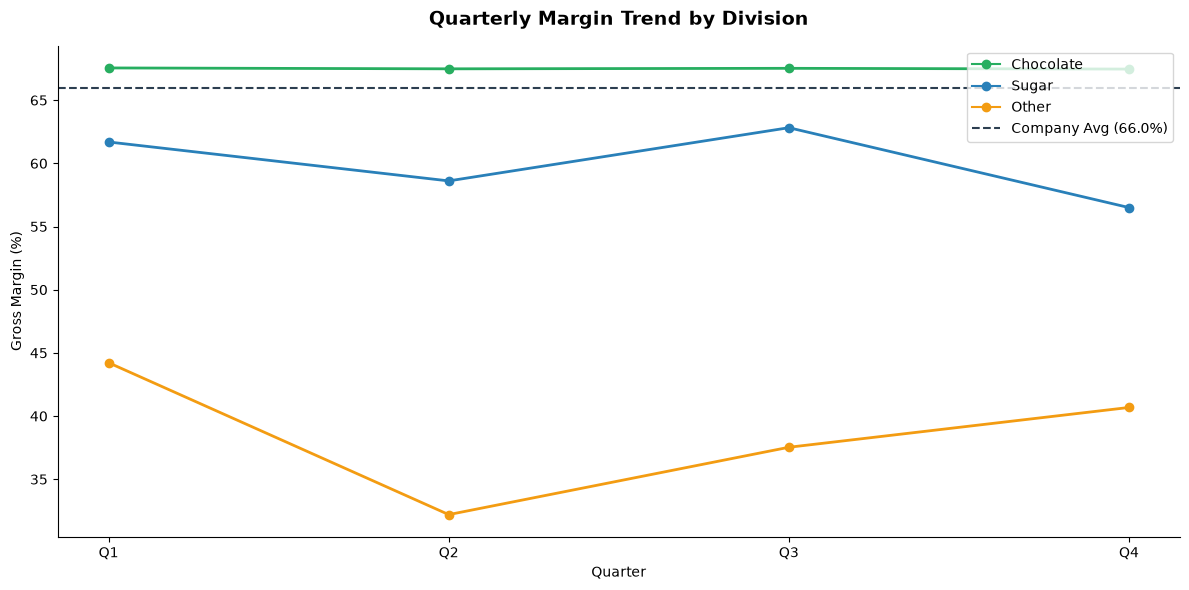

Chart 15 saved


In [10]:
fig, ax = plt.subplots()

for division, color in DIVISION_COLORS.items():
    subset = quarterly_div[quarterly_div['Division'] == division]
    ax.plot(subset['Quarter_Label'], subset['Avg_Margin'],
            color=color, marker='o', linewidth=2, label=division)

ax.axhline(y=company_avg_margin, color=COLORS['primary'],
           linestyle='--', linewidth=1.5)

ax.set_title('Quarterly Margin Trend by Division', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Gross Margin (%)')
ax.set_xlabel('Quarter')

ax.legend(handles=[
    plt.Line2D([0], [0], color=DIVISION_COLORS[d], marker='o', label=d)
    for d in DIVISION_COLORS
] + [
    plt.Line2D([0], [0], color=COLORS['primary'], linestyle='--',
               label=f'Company Avg ({company_avg_margin:.1f}%)')
], loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/charts/15_division_quarterly_margin_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 15 saved")